# Predator - prey Jump Switch Flow 

This notebook is a personal implementation of some of the methods in  https://github.com/DGermano8/JSFOnlineDemo/blob/main/content/PredatorPreyExample.ipynb


In [2]:
import jsf 

## 1. Basic example 

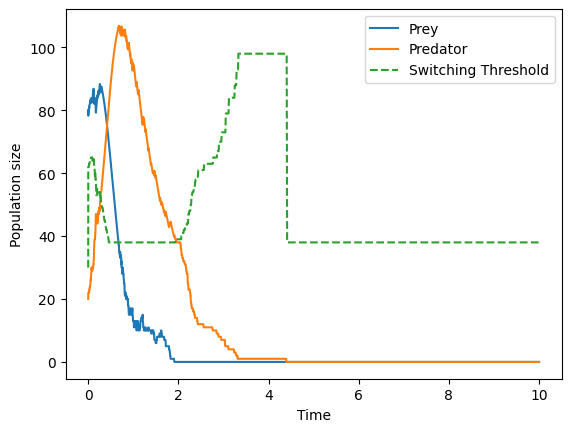

In [11]:
import numpy as np 
#Initial conditions
x0 = [80, 20]


#Rates
mA = 2.00
mB = 0.05
mC = 1.50
rates = lambda x, t: [mA * x[0],
                      mC * x[1],
                      mB * x[0] * x[1]]


#Stoichiometric matrices
reactant_matrix = [[1 , 0],
                   [0 , 1],
                   [1 , 1]]

product_matrix = [[2 , 0],
                  [0 , 0],
                  [0 , 2]]

stoich = {
    "nu": [ [a - b for a, b in zip(r1, r2)]
        for r1, r2 in zip(product_matrix, reactant_matrix) ],
    "DoDisc": [1, 1],
    "nuReactant": reactant_matrix,
    "nuProduct": product_matrix,
}


# Create Jacobian function with fixed parameters
from jsf.dynamic_scaling import jacobian_lotka_volterra
def lotka_volterra_jacobian(state):
    return jacobian_lotka_volterra(state, mA, mB, mC)

#Options
omega = 30
my_opts = {
            "EnforceDo": [0, 0],
            "dt": 0.01,
            "SwitchingThreshold": [omega, omega],
            'alpha': mA,
            'beta': mB,
            'gamma': mC,
            'seed':28,
        'EnableDynamicThreshold': True,
        "DynamicThresholdStrategy": "jacobian_based",
        "JacobianParams": {
            "jacobian_func": lotka_volterra_jacobian,
            "omega_min": 5.0,
            "omega_max": 100.0,
            "k": 3.0,
            "score_threshold": 0.2,
            "debug": False  # Disable debug output for cleaner tests
        },
        'seed': 2
           }
t_max = 10



sim = jsf.jsf(x0, rates, stoich, t_max, config=my_opts, method="operator-splitting")

import matplotlib.pyplot as plt
plt.plot(sim[1], sim[0][0], label="Prey")
plt.plot(sim[1], sim[0][1], label="Predator")
if my_opts['EnableDynamicThreshold']:
    plt.plot(sim[1], np.vstack(sim[2])[:,0], label="Switching Threshold",linestyle="--",c='C2')
else:
    plt.plot(sim[1], np.ones(len(sim[1])) * omega, label="Switching Threshold",linestyle="--",c='C2')

plt.xlabel("Time")
plt.ylabel("Population size")
plt.legend()
plt.show()

In [12]:
sim[0][0][-1]

0